# Executive visuals

Audience: non-technical executives. Each figure makes **one** point, carries an **assertion headline**, uses **honest axes**, and strips everything else (Storytelling-with-Data style: gray context, one slate-blue accent, direct labels, no legends).

Five finals:
1. Built beats bought (vertical bars)
2. Reliance on purchased scores fell 59% (slopegraph)
3. 62% of the power is data we own (stacked bar)
4. Where that power lives (family breakdown)
5. AUC as each layer of our own data is added (converging curve)

Numbers come from saved OOF results plus one model fit; visual 5 computes the layer-by-layer progression once (a few min) and caches it to `iteration_results.csv`.

In [1]:
import sys; sys.path.append("..")
import json, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from src.data import INTERIM, load_selected, load_master

FIGS = Path("../data/context/reports/figures"); FIGS.mkdir(parents=True, exist_ok=True)
base = json.loads((INTERIM / "baseline.json").read_text())
eng = json.loads((INTERIM / "engineered.json").read_text())

GRAY, GRAYD, TXT, ACCENT = "#C9C9C9", "#8A8A8A", "#404040", "#3F7CAC"
plt.rcParams.update({"font.size": 11, "figure.dpi": 120, "text.color": TXT,
                     "axes.labelcolor": TXT, "xtick.color": TXT, "ytick.color": TXT})

def strip(ax, keepx=False, keepy=False):
    for s in ax.spines.values():
        s.set_visible(False)
    ax.grid(False); ax.tick_params(length=0)
    if not keepx: ax.set_xticks([])
    if not keepy: ax.set_yticks([])

def finish(fig, name):
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight"); plt.show()

is_ext = lambda c: "ext_source" in c.lower() or c.lower().startswith("ext_calc_")
before = base["combined"] - base["internal only"]
after = eng["combined"] - eng["internal only"]
drop = (before - after) / before * 100
vals = [base["external only"], eng["internal only"], eng["combined"]]
labels3 = ["Bought only", "Built only", "Built + Bought"]
print(f"bought {vals[0]:.3f} | built {vals[1]:.3f} | combined {vals[2]:.3f} | drop {drop:.0f}%")

bought 0.720 | built 0.769 | combined 0.794 | drop 58%


## Visual 1 - Our built data alone beats bought

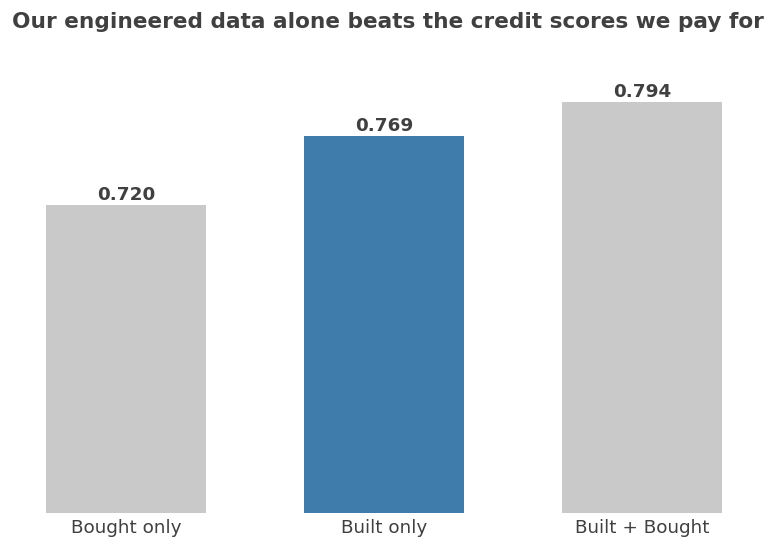

In [2]:
cols = [GRAY, ACCENT, GRAY]
fig, ax = plt.subplots(figsize=(8, 5))
b = ax.bar(labels3, vals, color=cols, width=0.62)
for x, v in zip(b, vals):
    ax.text(x.get_x() + x.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0.5, 0.83); strip(ax, keepx=True)
ax.set_title("Our engineered data alone beats the credit scores we pay for",
             loc="left", fontweight="bold", fontsize=13, pad=14)
finish(fig, "exec1_built_beats_bought")

## Visual 2 - Engineering cut our reliance on the purchased scores

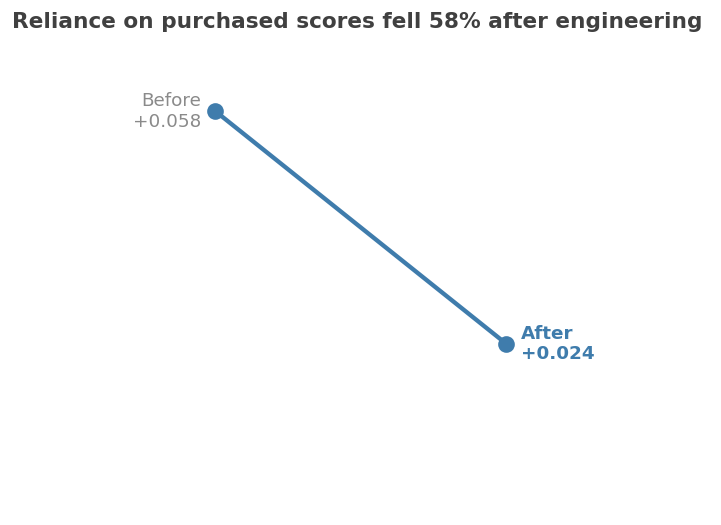

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot([0, 1], [before, after], color=ACCENT, lw=2.6, marker="o", ms=9)
ax.text(-0.05, before, f"Before\n+{before:.3f}", ha="right", va="center", color=GRAYD)
ax.text(1.05, after, f"After\n+{after:.3f}", ha="left", va="center", color=ACCENT, fontweight="bold")
ax.set_xlim(-0.7, 1.7); ax.set_ylim(0, before * 1.15); strip(ax)
ax.set_title(f"Reliance on purchased scores fell {drop:.0f}% after engineering",
             loc="left", fontweight="bold", fontsize=13, pad=14)
finish(fig, "exec2_reliance_slope")

## Visuals 3 & 4 - Where the model's predictive power comes from
One model fit; each feature's gain grouped into bought (external scores) vs. built, then by source family.

In [4]:
Xs, ys = load_selected()
clf = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                         subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                         n_jobs=-1, verbose=-1).fit(Xs, ys)
imp = pd.Series(clf.booster_.feature_importance("gain"), index=Xs.columns)
bought_share = imp[[c for c in imp.index if is_ext(c)]].sum() / imp.sum()
built_share = 1 - bought_share

def fam(c):
    cl = c.lower()
    if is_ext(c): return "Purchased scores"
    if cl.startswith(("bureau", "bb_")): return "Credit bureau"
    if cl.startswith("prev"): return "Prior applications"
    if cl.startswith("pos"): return "POS / cash loans"
    if cl.startswith("ins"): return "Installment history"
    if cl.startswith("cc"): return "Credit card"
    if cl.startswith(("x_pca", "x_kmeans", "x_ae")): return "Learned features"
    if cl.startswith("x_"): return "Cross-table"
    return "Application form"

family = (imp.groupby(imp.index.map(fam)).sum() / imp.sum()).sort_values()
print(f"built {built_share:.0%} | bought {bought_share:.0%}")

built 62% | bought 38%


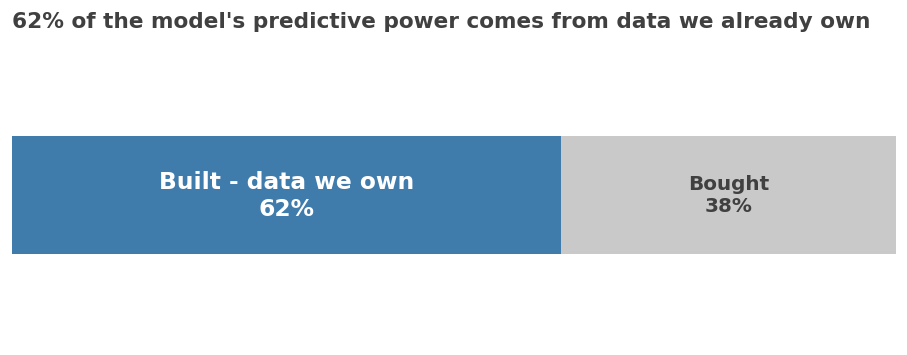

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.barh(0, built_share, color=ACCENT); ax.barh(0, bought_share, left=built_share, color=GRAY)
ax.text(built_share / 2, 0, f"Built - data we own\n{built_share:.0%}", ha="center", va="center",
        color="white", fontweight="bold", fontsize=14)
ax.text(built_share + bought_share / 2, 0, f"Bought\n{bought_share:.0%}", ha="center", va="center",
        color=TXT, fontweight="bold", fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(-1, 1); strip(ax)
ax.set_title(f"{built_share:.0%} of the model's predictive power comes from data we already own",
             loc="left", fontweight="bold", fontsize=13, pad=12)
finish(fig, "exec3_power_split")

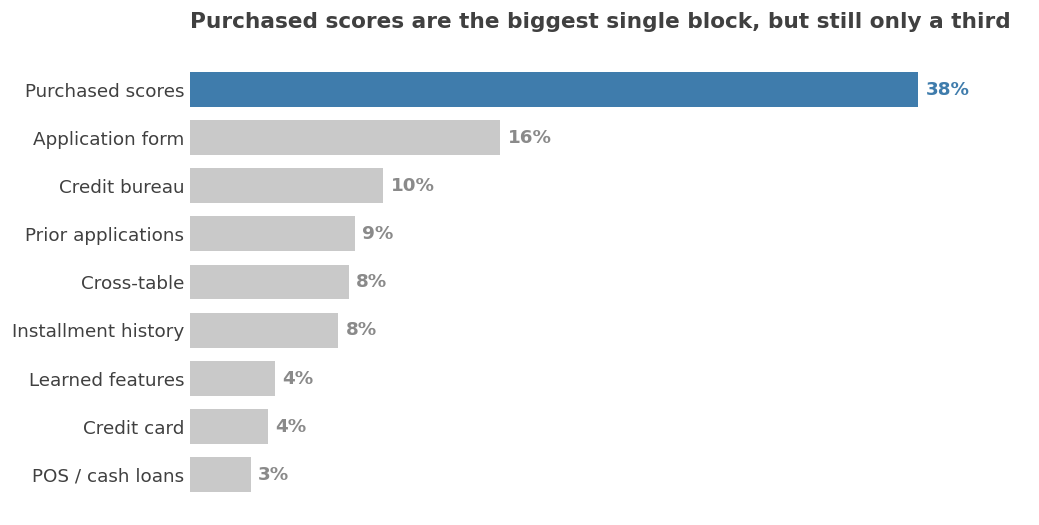

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
fcols = [ACCENT if k == "Purchased scores" else GRAY for k in family.index]
ax.barh(range(len(family)), family.values, color=fcols, height=0.72)
for i, v in enumerate(family.values):
    ax.text(v + 0.004, i, f"{v:.0%}", va="center", fontweight="bold",
            color=(ACCENT if family.index[i] == "Purchased scores" else GRAYD))
ax.set_yticks(range(len(family))); ax.set_yticklabels(family.index, fontsize=11)
strip(ax, keepy=True); ax.set_xlim(0, family.max() * 1.15)
ax.set_title("Purchased scores are the biggest single block, but still only a third",
             loc="left", fontweight="bold", fontsize=13, pad=14)
finish(fig, "exec4_power_by_family")

## Visual 6 - The three scores we buy are the strongest predictors

Feature importance from a model fit on the three raw purchased scores (EXT_SOURCE 1/2/3) plus the internal features, so the chart shows the actual scores we buy rather than the engineered versions of them. The three external scores top the list; our own features follow. Individually the scores dominate, though collectively the many internal features carry more (Visual 4).

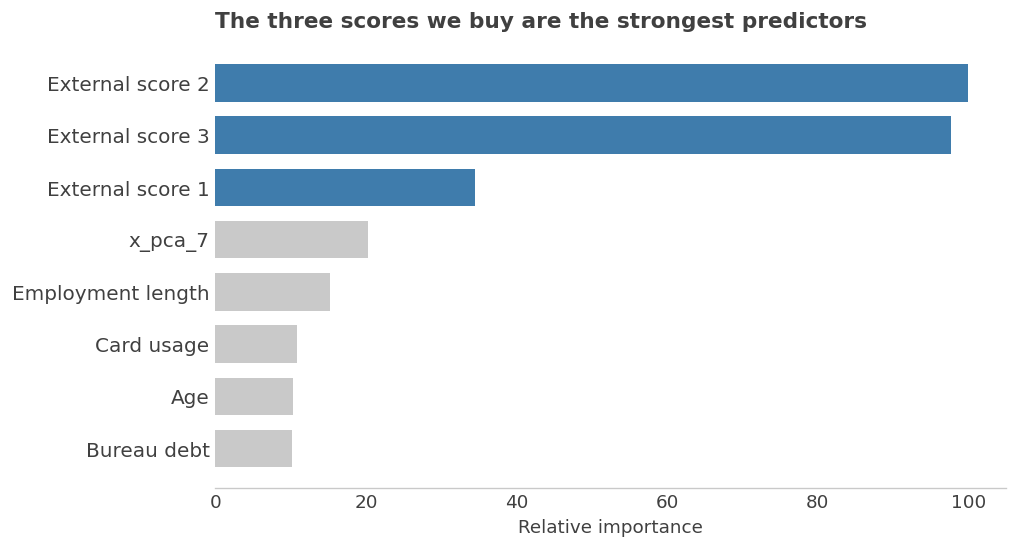

In [7]:
from src.data import RAW

internal = [c for c in Xs.columns if not is_ext(c)]
raw_ext = pd.read_csv(RAW / "application_train.csv",
                      usecols=["SK_ID_CURR", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]).set_index("SK_ID_CURR").reindex(Xs.index)
Xa = Xs[internal].join(raw_ext)
clf6 = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                          n_jobs=-1, verbose=-1).fit(Xa, ys)
imp6 = pd.Series(clf6.booster_.feature_importance("gain"), index=Xa.columns).sort_values(ascending=False)

LAB = {"EXT_SOURCE_2": "External score 2", "EXT_SOURCE_3": "External score 3", "EXT_SOURCE_1": "External score 1",
       "DAYS_EMPLOYED": "Employment length", "bureau_debt_credit": "Bureau debt", "credit_to_annuity": "Loan-to-payment",
       "x_pca_8": "Learned pattern", "DAYS_BIRTH": "Age", "cc_util_max_6": "Card usage",
       "ins_last_loan_late_share": "Recent late payments"}
top = imp6.head(8)[::-1]
vals = top.values / top.values.max() * 100
cols = [ACCENT if is_ext(c) else GRAY for c in top.index]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(range(len(top)), vals, color=cols, height=0.72)
ax.set_yticks(range(len(top))); ax.set_yticklabels([LAB.get(c, c) for c in top.index], fontsize=12)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRAY)
ax.tick_params(length=0)
ax.set_xlabel("Relative importance", fontsize=11)
ax.set_title("The three scores we buy are the strongest predictors",
             loc="left", fontweight="bold", fontsize=13, pad=10)
finish(fig, "exec6_importance")

## Visual 5 - AUC as each layer of our own data is added
Two curves - built (internal only) and built + bought - as one data source is stacked on at a time. The gap between them is what the purchased scores are worth at that point; it should shrink as our own data accumulates. Computes the progression once (a few min) and caches it.

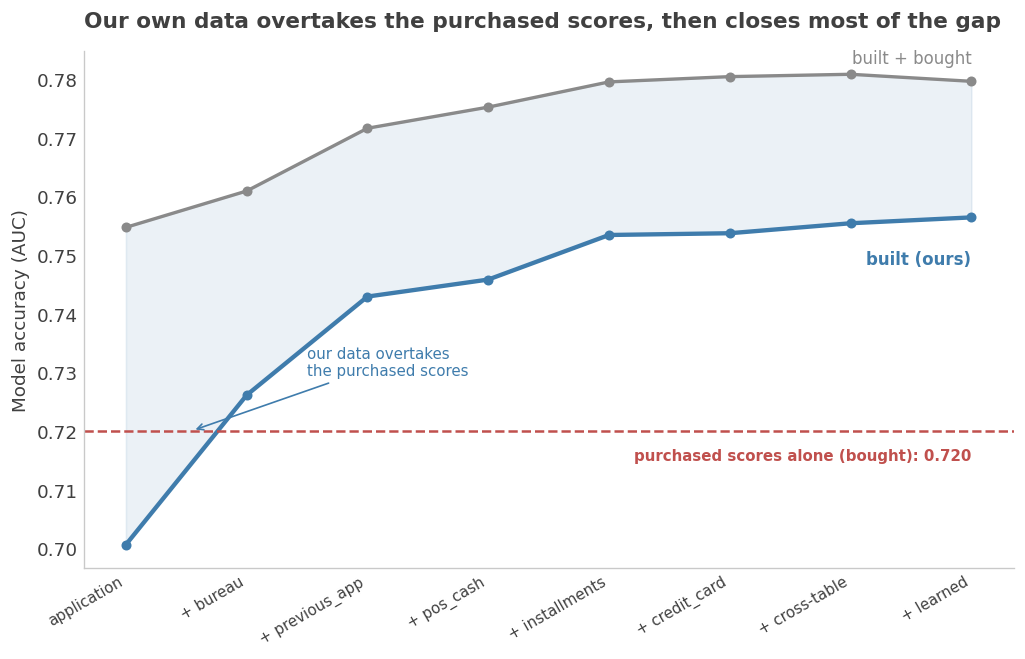

In [8]:
p = INTERIM / "iteration_results.csv"
if not p.exists():
    print("computing layer-by-layer progression (a few min)...")
    from src.progression import run_progression
    def fast_gbm():
        return lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                                  subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                                  n_jobs=-1, verbose=-1)
    Xm, ym = load_master()
    run_progression(Xm, ym, fast_gbm, axes=("source",)).to_csv(p, index=False)

d = pd.read_csv(p)
d = d[d["axis"] == "source"].reset_index(drop=True)
x = list(range(len(d)))
ext_only = base["external only"]
REF = "#C0504D"

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(x, d["auc_combined"], color=GRAYD, lw=2, marker="o", ms=5)
ax.plot(x, d["auc_internal"], color=ACCENT, lw=2.6, marker="o", ms=5)
ax.fill_between(x, d["auc_internal"], d["auc_combined"], color=ACCENT, alpha=0.10)
ax.axhline(ext_only, color=REF, ls="--", lw=1.5)
ax.text(x[-1], ext_only - 0.003, f"purchased scores alone (bought): {ext_only:.3f}",
        color=REF, ha="right", va="top", fontsize=9, fontweight="bold")
ax.text(x[-1], d["auc_combined"].iloc[-1] + 0.003, "built + bought", color=GRAYD, ha="right", fontsize=10)
ax.text(x[-1], d["auc_internal"].iloc[-1] - 0.008, "built (ours)", color=ACCENT, ha="right", fontweight="bold", fontsize=10)
ax.annotate("our data overtakes\nthe purchased scores", xy=(0.55, ext_only), xytext=(1.5, 0.729),
            fontsize=9, color=ACCENT, ha="left", va="bottom",
            arrowprops=dict(arrowstyle="->", color=ACCENT))
ax.set_xticks(x); ax.set_xticklabels(d["step"], rotation=30, ha="right", fontsize=9)
strip(ax, keepx=True, keepy=True)
for s in ["left", "bottom"]:
    ax.spines[s].set_visible(True); ax.spines[s].set_color(GRAY)
ax.set_ylabel("Model accuracy (AUC)")
ax.set_title("Our own data overtakes the purchased scores, then closes most of the gap",
             loc="left", fontweight="bold", fontsize=13, pad=14)
finish(fig, "exec5_auc_by_layer")